In [ ]:
# CSE425 — End-to-End Inference Demo
'''
Loads one preprocessed graph ('sample_001.pt') and runs the FusionModel
on it to demonstrate the full inference pipeline.

**Graph details:** 19 nodes, 25-dim node features, 304 directed edges,
label 'y=0', genre 'blues', track 'track_001'.
'''

In [9]:
!pip install -q torch-geometric transformers

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import BertModel, BertTokenizer
from torch_geometric.nn import GraphSAGE, GATConv, global_mean_pool

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("Torch:", torch.__version__)

Device: cpu
Torch: 2.11.0+cpu


In [11]:
sample = torch.load("/content/sample_001.pt", map_location="cpu", weights_only=False)

print("Type:", type(sample).__name__)
print(f"Nodes:          {sample.num_nodes}")
print(f"Edges:          {sample.num_edges}")
print(f"Node features:  {sample.x.shape}")
print(f"Label y:        {sample.y.item()}")
print(f"Track ID:       {sample.track_id}")
print(f"Genre:          {sample.genre}")

Type: Data
Nodes:          19
Edges:          304
Node features:  torch.Size([19, 25])
Label y:        0
Track ID:       track_001
Genre:          blues


In [12]:
class GATEncoder(nn.Module):
    def __init__(self, in_dim, hid, out, layers, dropout, heads=4):
        super().__init__()
        self.convs = nn.ModuleList(); self.bns = nn.ModuleList()
        self.dropout = nn.Dropout(dropout)
        for i in range(layers):
            in_ch = in_dim if i == 0 else hid
            out_ch = hid if i < layers - 1 else out
            h = heads if i < layers - 1 else 1
            self.convs.append(GATConv(in_ch, out_ch // h, heads=h,
                                      concat=(h > 1), dropout=dropout))
            if i < layers - 1:
                self.bns.append(nn.BatchNorm1d(out_ch))

    def forward(self, x, ei):
        for i, c in enumerate(self.convs):
            x = c(x, ei)
            if i < len(self.convs) - 1:
                x = self.dropout(F.relu(self.bns[i](x)))
        return x


class FusionModel(nn.Module):
    def __init__(self, gnn_type="graphsage", gnn_input_dim=12,
                 gnn_hidden_dim=128, gnn_output_dim=128, gnn_num_layers=2,
                 bert_model_name="bert-base-uncased",
                 fusion_method="cross_attention", num_tags=60,
                 num_heads=4, dropout=0.3, freeze_bert=False):
        super().__init__()
        self.fusion_method = fusion_method

        if gnn_type == "graphsage":
            self.gnn = GraphSAGE(
                in_channels=gnn_input_dim,
                hidden_channels=gnn_hidden_dim,
                out_channels=gnn_output_dim,
                num_layers=gnn_num_layers,
                dropout=dropout,
                norm=nn.BatchNorm1d(gnn_hidden_dim),
            )
        elif gnn_type == "gat":
            self.gnn = GATEncoder(gnn_input_dim, gnn_hidden_dim,
                                  gnn_output_dim, gnn_num_layers, dropout)
        else:
            raise ValueError(gnn_type)

        self.bert = BertModel.from_pretrained(bert_model_name)
        if freeze_bert:
            for p in self.bert.parameters():
                p.requires_grad = False
        bert_dim = self.bert.config.hidden_size

        if fusion_method == "concat":
            self.text_proj = nn.Linear(bert_dim, gnn_output_dim)
            self.fuse = nn.Sequential(
                nn.Linear(gnn_output_dim * 2, gnn_output_dim),
                nn.ReLU(), nn.Dropout(dropout))
            head_in = gnn_output_dim
        elif fusion_method == "cross_attention":
            self.q_proj = nn.Linear(gnn_output_dim, gnn_output_dim)
            self.kv_proj = nn.Linear(bert_dim, gnn_output_dim)
            self.attn = nn.MultiheadAttention(gnn_output_dim, num_heads,
                                              dropout=dropout, batch_first=True)
            head_in = gnn_output_dim
        elif fusion_method == "bert_only":
            self.text_proj = nn.Linear(bert_dim, gnn_output_dim)
            head_in = gnn_output_dim
        elif fusion_method == "gnn_only":
            head_in = gnn_output_dim
        else:
            raise ValueError(fusion_method)

        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(head_in, head_in),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_in, num_tags),
        )

    def forward(self, graph_x, edge_index, graph_batch,
                input_ids, attention_mask, return_embeddings=False):
        g = None
        if self.fusion_method != "bert_only":
            node = self.gnn(graph_x, edge_index)
            g = global_mean_pool(node, graph_batch)

        t_cls = t_seq = None
        if self.fusion_method != "gnn_only":
            bo = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            mask = attention_mask.unsqueeze(-1).float()
            t_cls = (bo.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1e-6)
            t_seq = bo.last_hidden_state

        if self.fusion_method == "concat":
            fused = self.fuse(torch.cat([g, self.text_proj(t_cls)], 1))
        elif self.fusion_method == "cross_attention":
            kv = self.kv_proj(t_seq)
            q = self.q_proj(g).unsqueeze(1)
            a, _ = self.attn(q, kv, kv, need_weights=False)
            fused = a.squeeze(1)
        elif self.fusion_method == "bert_only":
            fused = self.text_proj(t_cls)
        elif self.fusion_method == "gnn_only":
            fused = g

        fused = self.dropout(fused)
        out = {"tag_logits": self.head(fused)}
        if return_embeddings:
            out["embeddings"] = fused
        return out

In [13]:
model = FusionModel(
    gnn_type="graphsage",
    gnn_input_dim=25,          # matches sample.x.shape[1]
    gnn_hidden_dim=128,
    gnn_output_dim=128,
    gnn_num_layers=2,
    bert_model_name="bert-base-uncased",
    fusion_method="cross_attention",
    num_tags=60,
    num_heads=4,
    dropout=0.3,
    freeze_bert=True,
).to(device)
model.eval()

total = sum(p.numel() for p in model.parameters())
print(f"Model instantiated. Total params: {total:,}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model instantiated. Total params: 109,727,164


In [14]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
text = "A calm acoustic blues track with guitar and soft percussion"
enc = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128)

x          = sample.x.to(device)
edge_index = sample.edge_index.to(device)
batch      = torch.zeros(x.size(0), dtype=torch.long, device=device)

with torch.no_grad():
    out = model(
        x, edge_index, batch,
        enc["input_ids"].to(device),
        enc["attention_mask"].to(device),
        return_embeddings=True,
    )

logits = out["tag_logits"]
embeddings = out["embeddings"]

print("Tag logits shape:", logits.shape)
print("Embedding shape: ", embeddings.shape)
print("Top-5 tag indices:", logits.topk(5, dim=-1).indices.tolist())
print("Top-5 scores:     ", logits.topk(5, dim=-1).values.tolist())

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tag logits shape: torch.Size([1, 60])
Embedding shape:  torch.Size([1, 128])
Top-5 tag indices: [[54, 17, 19, 26, 8]]
Top-5 scores:      [[0.11488014459609985, 0.1077185720205307, 0.09600500762462616, 0.08335068076848984, 0.07795817404985428]]


In [16]:
import ast
import pandas as pd
from collections import Counter

# --- Rebuild vocab exactly like training did ---
def parse_aspect_list(raw):
    if not isinstance(raw, str):
        return []
    try:
        items = ast.literal_eval(raw)
    except (ValueError, SyntaxError):
        return []
    return [str(x).strip().lower() for x in items if str(x).strip()]

def build_tag_vocab(df, top_k=60, min_count=5):
    counter = Counter()
    for raw in df["aspect_list"]:
        counter.update(parse_aspect_list(raw))
    return [t for t, c in counter.most_common() if c >= min_count][:top_k]

df = pd.read_csv("/content/musiccaps-public.csv")
vocab = build_tag_vocab(df, top_k=60, min_count=5)

print(f"Vocab size: {len(vocab)}")
print("First 10 tags:", vocab[:10])

Vocab size: 60
First 10 tags: ['low quality', 'instrumental', 'emotional', 'noisy', 'passionate', 'medium tempo', 'energetic', 'amateur recording', 'live performance', 'slow tempo']


In [18]:
scores = logits[0].cpu()
top5_scores, top5_idx = scores.topk(5)

print("\nPredicted tags for this clip:")
print("-" * 45)
for idx, score in zip(top5_idx.tolist(), top5_scores.tolist()):
    tag = vocab[idx] if idx < len(vocab) else f"<idx {idx}>"
    print(f"  {tag:20s}  score={score:+.3f}")

print(f"\nGround-truth label: y={sample.y.item()}")
print(f"Genre: {sample.genre}  |  Track: {sample.track_id}")


Predicted tags for this clip:
---------------------------------------------
  no other instruments  score=+0.115
  instrumental music    score=+0.108
  piano                 score=+0.096
  moderate tempo        score=+0.083
  live performance      score=+0.078

Ground-truth label: y=0
Genre: blues  |  Track: track_001


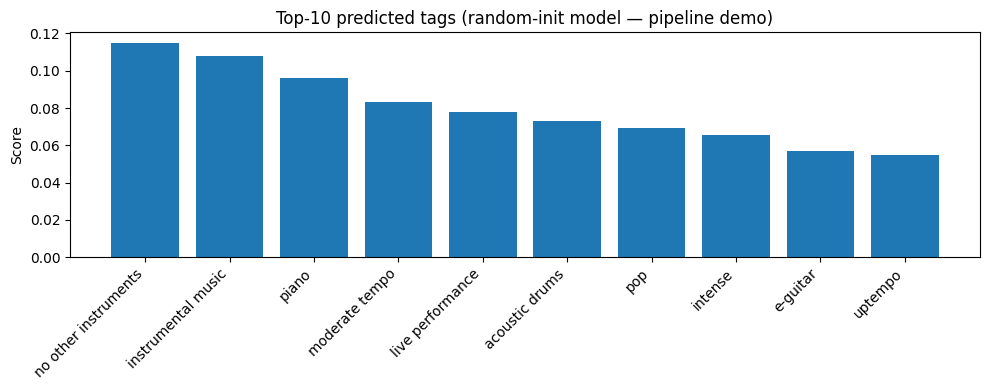

In [20]:
import matplotlib.pyplot as plt

scores = logits[0].cpu().numpy()
top10_scores, top10_idx = torch.from_numpy(scores).topk(10)

labels = [vocab[i] if i < len(vocab) else f"idx{i}" for i in top10_idx.tolist()]

plt.figure(figsize=(10, 4))
plt.bar(range(len(labels)), top10_scores.tolist())
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.title("Top-10 predicted tags (random-init model — pipeline demo)")
plt.ylabel("Score")
plt.tight_layout()
plt.show()